## **A) LangGraph**

LangChain is the name of the company that provides different services under the following names :
- **LangChain** : For the GenAI applications. It is kind of a wrapper for LLM integration, embedding, Vector Database, prompt template, etc. It also provides some classes for Agentic AI implementation but you will not have low-level control over that. 
- **LangGraph** : Specifically made to make agentic AI implementations. Make agentic flow from scratch. 
- **LangSmith/Langfuse** : For Observability and logging purposes. 
- **Langflow** : Helps to visualise flow, majorly a visualisation platform. 

### **1) Introduction of LangGraph**

LangGraph is an orchestrator framework which means we can connect multiple components to it and run them according to the flow. Inside the orchestrator we define a pipeline and inside the pipeline we add the components and arrangement inside the pipeline the flow is stablished and components are executed. 

Here every code is written in the form of nodes and edges. Nodes can be visualised as functions and functions can be connected to different edges. 

Information flows between nodes as states and edges are something that connects one node to another. 

1) Node : Function
2) Edge : Connection between the nodes
3) State : State is working data flowing between the nodes. State is passing the information from one node to another node while maintaining the state.

There are atleast 4 ways of creating the State
1) TypedDict : 
class State(TypedDict):
    text:str

2) Dataclass : 
@dataclass
class State:
    text : str

3) Pydantic : 
class State(BaseModel):
    text : str

4) Built in MessagesState (from LangGraph) : 
messages + add_messages reducer





Edges can be of 2 types :
- Sequential edges
- Conditional edges 

Q : Why do we use TypedDict for creating State objects?

Answer: because TypedDict gives you a clear, typed definition of what data the state is expected to contain, while still keeping the state as a normal Python dictionary.

Q: What is the purpose of START and END in StateGraph?

Answer: START marks the entry point of the graph (initial input), END marks the exit point (final output).

##### **Basic Understanding of LangChain structure - Implementation 1**

In [1]:
# A simple general function Call

def hello_node(input:str): # Here you already defined the class of input by str
    return {"message": f"Hello,{input}"}

hello_node("Hemant")

{'message': 'Hello,Hemant'}

In [2]:
from typing_extensions import TypedDict

In [3]:
class State(TypedDict): # Here you are creating a custom class named as State which accepts TypedDict. TypedDict can store the information in dictionary format. 
    message: str

In [4]:
state : State = {"message" : "Hello Python!"} 

# state is the variable and State is the class defined as above. 
# Here you are creating a dictionary with key as message and value as Hello Python!

In [5]:
State

__main__.State

In [6]:
state

{'message': 'Hello Python!'}

In [7]:
def hello_node(state:State): # Here you already defined the class of input by State which is nothing but a custom class defined above
    return {"message": f"Hello {state['message']}"}

# This is very much analoguous to the above function definition : 
# def hello_node(input:str): # Here you already defined the class of input by str
#    return {"message": f"Hello,{input}"}

In [8]:
from langgraph.graph import StateGraph, START, END

In [9]:
builder = StateGraph(State)
builder.add_node("First_hello_node", hello_node) # defined as name and then the function

builder.add_edge(START, "First_hello_node")
builder.add_edge("First_hello_node", END)

In [10]:
graph = builder.compile()

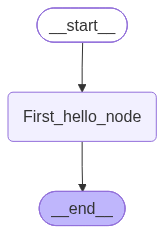

In [11]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"message": "Hemant"})

{'message': 'Hello Hemant'}

In [13]:
result = graph.invoke({"message": "Hemant"})
result["message"]

'Hello Hemant'

##### **Implementation 2**

In [14]:
class Sunny(TypedDict):
    text: str

In [15]:
def function1(state:Sunny):
    print(f"State from first function : {state}")
    return {
        "text": state["text"] + " from first function"
        }

In [16]:
def function2(state:Sunny):
    print(f"State from second function : {state}")
    return {
        "text": state["text"] + " Dhingra from second function"
        }

In [17]:
workflow = StateGraph(Sunny)
workflow.add_node("fun1", function1)
workflow.add_node("fun2", function2)

In [18]:
workflow.add_edge(START, "fun1")
workflow.add_edge("fun1", "fun2")
workflow.add_edge("fun2", END)

In [19]:
app = workflow.compile()

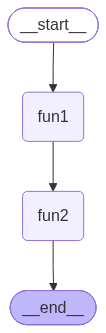

In [20]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
result

{'message': 'Hello Hemant'}

- State from first function before return (**this is input to the first function**) : {'text': 'Hi this is Hemant'}
- State from second function before return statement(**this is output from the first function and hence input to second function**): {'text': 'Hi this is Hemant from first function'}
- **final state after second function output** {'text': 'Hi this is Hemant from first function Dhingra from second function'}

##### **Implementation 3 (with LLM Call)**

In [22]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

In [23]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [24]:
if not os.getenv("GROQ_API_KEY"):
    raise ValueError("Please set the GROQ_API_KEY environment variable.")

In [25]:
MODEL_NAME = "openai/gpt-oss-20b"
llm = ChatGroq(
    model_name=MODEL_NAME, 
    temperature =0.6, 
    api_key=os.getenv("GROQ_API_KEY"),
    reasoning_format="hidden")

response = llm.invoke("Hi")
print(response.content)

Hello! How can I help you today?


In [26]:
from langgraph.graph import MessagesState ## This is a built in state provided by langgraph which is used to store the messages in a list format.

In [27]:
def call_model(state : MessagesState):
    print("\n=============================================")
    print("MYBOT NODE")
    print("\n=============================================")
    
    # Get complete conversation history
    messages = state["messages"]
    print("Current Message:",messages)
    # Send complete message history to LLM
    
    response = llm.invoke(messages)
    print("\n Model Response:", response.content)
    ## MessagesState INTERNALLY USES ADD_MESSAGES REDUCER THEREFORE THE NEW AIMessage WILL BE ADDED TO THE EXISTING LIST OF MESSAGES IN THE STATE
    return {"messages": [response]}

In [28]:
workflow = StateGraph(MessagesState)

In [29]:
workflow.add_node("mybot",call_model)

In [30]:
workflow.add_edge(START,"mybot")
workflow.add_edge("mybot",END)

In [31]:
app = workflow.compile()

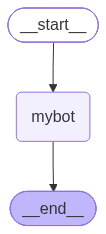

In [32]:
from IPython.display import (
    Image,
    display,
)


display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [33]:
input = {"messages": [HumanMessage(content="Hi hello, how are you?")]}

In [34]:
result = app.invoke(input)


MYBOT NODE

Current Message: [HumanMessage(content='Hi hello, how are you?', additional_kwargs={}, response_metadata={}, id='7fdd8bb7-c629-4af6-b21d-d0dcc1e9a259')]

 Model Response: Hi there! I’m doing great—thanks for asking. How about you? Anything interesting on your mind today?


##### **Implementation 4 (with LLM Call + Advanced State)**

In [35]:
from typing_extensions import TypedDict, NotRequired
from langchain_core.messages import AIMessage

In [36]:
class State(TypedDict):
    # User input
    question: str

    # Generated answer
    answer: NotRequired[str]
    
    # Complete model response
    response: NotRequired[AIMessage]
    
    # Token information
    input_tokens: NotRequired[int]
    output_tokens: NotRequired[int]
    total_tokens: NotRequired[int]

In [37]:
def llm_node(state: State):
    print("\n========================")
    print("LLM NODE")
    print("========================")
    
    response = llm.invoke(state["question"])
    print("\nGenerated Answer:\n",response.content)
    
    # IMPORTANT:
    # We are NOT counting tokens here.
    # We simply save the complete AIMessage
    # so the next node can inspect its token metadata.
    return { "answer": response.content, "response": response}

In [38]:
response= llm.invoke("How are you?")
response

AIMessage(content='I’m just a bundle of code, so I don’t have feelings, but I’m running smoothly and ready to help you! What’s on your mind today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 75, 'total_tokens': 161, 'completion_time': 0.089352306, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.003643696, 'prompt_tokens_details': None, 'queue_time': 0.400072869, 'total_time': 0.092996002}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5979a0e1b7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09af0-833a-7db1-82ab-8597101c0359-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 86, 'total_tokens': 161, 'output_token_details': {'reasoning': 44}})

AIMessage(content='I’m doing great—thanks for asking! How about you?', 
additional_kwargs={}, 
response_metadata={'token_usage': 
                                {'completion_tokens': 62, 
                                'prompt_tokens': 75, 
                                'total_tokens': 137, 
                                'completion_time': 0.064324053, 
                                'completion_tokens_details': {'reasoning_tokens': 40}, 
                                'prompt_time': 0.004765223, 
                                'prompt_tokens_details': None, 
                                'queue_time': 0.307257064, 
                                'total_time': 0.069089276
                                }, 
                    'model_name': 'openai/gpt-oss-20b', 
                    'system_fingerprint': 'fp_66891002f6', 
                    'service_tier': 'on_demand', 
                    'finish_reason': 'stop', 
                    'logprobs': None, 
                    'model_provider': 'groq'
                    }, 
                    id='lc_run--01a0960b-5cb6-73e0-8455-23eb0fff244d-0', 
                    tool_calls=[], 
                    invalid_tool_calls=[], 
                    usage_metadata={
                                    'input_tokens': 75, 
                                    'output_tokens': 62, 
                                    'total_tokens': 137, 
                                    'output_token_details': {'reasoning': 40}
                                    }
            )


This gives you an understanding of the structure of the output from LLM call. 

In [39]:
def token_counter(state: State):
    print("\n========================")
    print("TOKEN COUNTER NODE")
    print("========================")
    
    response = state["response"]
    usage = response.usage_metadata or {}
    input_tokens = usage.get("input_tokens")
    output_tokens = usage.get("output_tokens")
    total_tokens = usage.get("total_tokens")

    print("Input Tokens:",input_tokens)
    print("Output Tokens:",output_tokens)
    print("Total Tokens:",total_tokens)

    return {"input_tokens": input_tokens, "output_tokens": output_tokens, "total_tokens": total_tokens}

In [40]:
workflow = StateGraph(State)

In [41]:
workflow.add_node("llm", llm_node)

In [42]:
workflow.add_node("token", token_counter)

In [43]:
workflow.add_edge(START, "llm")
workflow.add_edge("llm", "token")
workflow.add_edge("token", END)

In [44]:
app = workflow.compile()

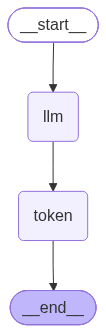

In [45]:
from IPython.display import (Image, display,)
display(Image(app.get_graph().draw_mermaid_png()))

In [46]:
result = app.invoke({"question": "Tell me about Tata Group in detail?"})
result


LLM NODE

Generated Answer:
 

TOKEN COUNTER NODE
Input Tokens: 79
Output Tokens: 2048
Total Tokens: 2127


{'question': 'Tell me about Tata Group in detail?',
 'answer': '',
 'response': AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 2048, 'prompt_tokens': 79, 'total_tokens': 2127, 'completion_time': 2.125237957, 'completion_tokens_details': {'reasoning_tokens': 2046}, 'prompt_time': 0.004684324, 'prompt_tokens_details': None, 'queue_time': 0.315340703, 'total_time': 2.129922281}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'length', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09af0-86b0-7fd1-aaf8-9bfbdffde480-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 'output_tokens': 2048, 'total_tokens': 2127, 'output_token_details': {'reasoning': 2046}}),
 'input_tokens': 79,
 'output_tokens': 2048,
 'total_tokens': 2127}

##### **Implementation 5 (Advanced Workflow with RAG)**

In [47]:
import os
import json
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
# LangChain
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import (TextLoader, DirectoryLoader)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_tavily import TavilySearch

# LangGraph
from langgraph.graph import (StateGraph, START, END,)

C:\Users\HP\AppData\Local\Temp\ipykernel_5568\2452827960.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import (TextLoader, DirectoryLoader)


In [48]:
MODEL_NAME = "openai/gpt-oss-20b"
llm = ChatGroq(
    model=MODEL_NAME,
    temperature=0.6,
    reasoning_format="hidden"
)


In [49]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.11'}}, output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000247D94C7CD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000247DB05FE10>, model_name='openai/gpt-oss-20b', temperature=0.6, reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [50]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

In [51]:
embedding_vector = embeddings.embed_query("Hello")
print("Embedding Dimension:",len(embedding_vector))

Embedding Dimension: 384


In [52]:
data_directory_path = os.path.join(os.getcwd(), "data")
file_path = os.path.join(data_directory_path, "sample.txt")
file_path

'c:\\Data_science\\Modern_route\\4) Agentic_AI\\data\\sample.txt'

In [53]:
loader = DirectoryLoader(
    data_directory_path, 
    glob="*.txt", 
    loader_cls=TextLoader,
    loader_kwargs={"encoding": "utf-8"}
    )
docs = loader.load()
print("Number of Documents Loaded:",len(docs))
docs

Number of Documents Loaded: 1


[Document(metadata={'source': 'c:\\Data_science\\Modern_route\\4) Agentic_AI\\data\\sample.txt'}, page_content='The United States economy is one of the largest and most diversified economies in the world. It is driven mainly by services, technology, finance, healthcare, manufacturing, retail, and consumer spending. The country has a strong startup ecosystem and is home to many global companies such as Microsoft, Apple, Amazon, Google, and Tesla. Innovation, research, advanced infrastructure, and access to capital support long-term economic growth. The U.S. dollar is widely used in international trade and is also a major global reserve currency. The country exports aircraft, software, pharmaceuticals, industrial equipment, agricultural goods, and financial services. Major economic challenges include inflation, public debt, income inequality, housing costs, and competition from other global economies. The Federal Reserve manages monetary policy by adjusting interest rates and controlling

In [54]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20)

In [55]:
new_docs = text_splitter.split_documents(docs)
print("Number of Documents after splitting:",len(new_docs))
new_docs

Number of Documents after splitting: 13


[Document(metadata={'source': 'c:\\Data_science\\Modern_route\\4) Agentic_AI\\data\\sample.txt'}, page_content='The United States economy is one of the largest and most diversified economies in the world. It is'),
 Document(metadata={'source': 'c:\\Data_science\\Modern_route\\4) Agentic_AI\\data\\sample.txt'}, page_content='in the world. It is driven mainly by services, technology, finance, healthcare, manufacturing,'),
 Document(metadata={'source': 'c:\\Data_science\\Modern_route\\4) Agentic_AI\\data\\sample.txt'}, page_content='manufacturing, retail, and consumer spending. The country has a strong startup ecosystem and is'),
 Document(metadata={'source': 'c:\\Data_science\\Modern_route\\4) Agentic_AI\\data\\sample.txt'}, page_content='ecosystem and is home to many global companies such as Microsoft, Apple, Amazon, Google, and Tesla.'),
 Document(metadata={'source': 'c:\\Data_science\\Modern_route\\4) Agentic_AI\\data\\sample.txt'}, page_content='Google, and Tesla. Innovation, researc

In [56]:
vector_store = Chroma(
    collection_name="usa_economy",
    embedding_function=embeddings
)

In [57]:
vector_store.add_documents(new_docs)

['923949b5-87a7-4d9a-b4f0-120cef78c015',
 'd1190c4d-331a-4acf-aefd-80b653699102',
 'ff8d74fe-67b3-44f7-90c5-975f2ca66e97',
 '3ee1e225-8a83-4cc2-b650-93d5a60f82d8',
 '5d947722-93f2-4e8a-a7b6-bdc574506e22',
 '39816a8e-79ef-4d01-a27a-f5a85b5ada09',
 'a73aa71c-8310-4a49-9854-6f7bcdecb906',
 '30c806a7-525c-4bb1-a0de-b9f678e7bc4a',
 'c8b54888-8094-400e-b085-31d2b7d022ad',
 '4973139e-8ffc-45c5-9c20-a785f88ac957',
 '7921813a-8ed2-4d2d-a124-922950030e19',
 '1ac6dd3f-4503-49fd-9e4b-3b5012b20d49',
 '7907834c-016a-4e0d-976c-bb22df2edd7a']

In [58]:
retriever = vector_store.as_retriever(
    search_kwargs={"k": 3})

In [59]:
test_documents = retriever.invoke("What is the GDP of USA?")
for docs in test_documents:
    print(docs.page_content)
    print("-"*50)

The United States economy is one of the largest and most diversified economies in the world. It is
--------------------------------------------------
economies. The Federal Reserve manages monetary policy by adjusting interest rates and controlling
--------------------------------------------------
goods, and financial services. Major economic challenges include inflation, public debt, income
--------------------------------------------------


In [60]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(
    api_key=os.getenv("TAVILY_API_KEY"),
    max_results=5,
    search_depth="advanced",
    topic = "general")


In [61]:
result = web_search.invoke({"query": "Do you know any Rumani Dua married to Shubham Bareja?"})
result

{'query': 'Do you know any Rumani Dua married to Shubham Bareja?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.youtube.com/watch?v=6Q9Yy7Bi-CQ',
   'title': 'Shubham weds Rumani Pagdi + Ghurchadi',
   'content': '# Shubham weds Rumani Pagdi + Ghurchadi\n## Channel: shubham bareja\n54 subscribers\n28 likes\n\n### Description\n1,470 views\nPosted: 2022-05-08 [...] [15:19] foreign\n[15:33] [Music]\n[15:51] oh\n[15:55] [Music]\n[16:24] foreign\n[16:28] [Music]\n[16:53] foreign\n[16:55] [Music]\n[17:15] foreign\n[17:16] [Music]\n[17:24] yay\n[17:27] [Music]\n[18:02] foreign\n[18:05] [Music]\n[18:43] is\n[18:45] [Music]\n[18:59] foreign\n[19:04] [Music]\n[19:11] [Music]\n[19:25] um\n[19:51] you\n[20:14] good morning\n[20:38] um\n[20:44] [Applause]\n[21:03] hello\n[21:08] [Applause]\n[21:18] hey\n[21:21] [Applause]\n[22:16] [Music]\n[22:23] okay\n[22:43] okay\n[22:45] [Music]\n[23:15] uh\n[23:31] [Music]\n[23:41] foreign\n[23:48] [Music]\n[2

In [62]:
## Pydantic modelling

class RouteDecision(BaseModel):
    route: Literal["RAG","LLM","WEB"] = Field(description="Node that should handle the user query")
    reasoning: str = Field(description="Reason for selecting this node")

In [63]:
RouteDecision.model_json_schema()

{'properties': {'route': {'description': 'Node that should handle the user query',
   'enum': ['RAG', 'LLM', 'WEB'],
   'title': 'Route',
   'type': 'string'},
  'reasoning': {'description': 'Reason for selecting this node',
   'title': 'Reasoning',
   'type': 'string'}},
 'required': ['route', 'reasoning'],
 'title': 'RouteDecision',
 'type': 'object'}

In [64]:
supervisor_model = llm.with_structured_output(
    schema=RouteDecision.model_json_schema(),
    method="json_schema")

In [65]:
supervisor_model.invoke("Hi")

{'route': 'LLM',
 'reasoning': 'User greeting, simple response best handled by LLM'}

In [66]:
supervisor_model.invoke("can you tell me the USA current GDP?")

{'route': 'LLM',
 'reasoning': 'The user requests up-to-date factual information (current GDP of the USA). This can be provided directly by the LLM, which has access to recent data or can generate an approximate answer. No external web or retrieval is required.'}

In [67]:
class ValidationResult(BaseModel):
    passed: bool = Field(description="True if the generated answer passes validation")
    score: int = Field(ge=0,le=10,description="Quality score from 0 to 10")
    feedback: str = Field(description="Reason for validation result")

In [68]:
validator_model = llm.with_structured_output(schema=ValidationResult.model_json_schema(),method="json_schema")

In [69]:
class AgentState(TypedDict, total=False):
    # Original user query
    question: str

    # Supervisor decision
    route: str
    
    # Supervisor reasoning
    route_reasoning: str
    
    # Context from RAG / Web
    context: str
    
    # Answer generated by RAG / LLM / Web
    draft_answer: str
    
    # Validation result
    validation_passed: bool
    validation_score: int
    validation_feedback: str
    
    # Retry information
    attempts: int
    
    # Keep track of previously used routes
    used_routes: list[str]
    
    # Answer shown to user only after validation
    final_answer: str

In [ ]:
def supervisor_node(state: AgentState):
    print("\n==============================")

    print("SUPERVISOR NODE")
    
    print("==============================")
    question = state["question"]
    previous_feedback = state.get("validation_feedback","")
    used_routes = state.get("used_routes",[])
    attempts = state.get("attempts",0)
    supervisor_prompt = f"""
                                You are the supervisor of an AI system.

                                Your responsibility is to decide which node should answer
                                the user's question.

                                You have three possible nodes:

                                1. RAG

                                Use RAG when:
                                - the question is related to the USA economy
                                - GDP of USA
                                - industrial growth of USA
                                - US economic sectors
                                - US debt
                                - US economic strengths
                                - USA economic information contained in our internal documents

                                The RAG knowledge base mainly contains information
                                about the United States economy.


                                2. WEB

                                Use WEB when:
                                - the user asks for current information
                                - today
                                - latest
                                - realtime
                                - recent news
                                - current stock price
                                - current weather
                                - latest economic information
                                - information that may have changed recently
                                - internal RAG documents may be outdated


                                3. LLM

                                Use LLM when:
                                - the question is general knowledge
                                - casual conversation
                                - greeting
                                - conceptual question
                                - question unrelated to the USA knowledge base
                                - information does not require current internet data


                                User Question: {question}
                                Routes already attempted: {used_routes}
                                Previous validation feedback: {previous_feedback}

                                Important:

                                If a previous answer failed validation, use the validation feedback to decide whether another information source should be selected. Return the best route.
                                """


    decision = supervisor_model.invoke(supervisor_prompt)
    route = decision["route"]
    reasoning = decision["reasoning"]

    print("Selected Route:",route)
    print("Reasoning:",reasoning)
    updated_routes = (used_routes + [route])


    return {

        "route": route,

        "route_reasoning": reasoning,

        "attempts": attempts + 1,

        "used_routes": updated_routes,

        # Clear previous attempt
        "context": "",

        "draft_answer": "",

    }

In [71]:
def router(state: AgentState):

    print(
        "\n-> ROUTER ->"
    )


    route = state["route"]


    print(
        "Routing to:",
        route
    )


    return route

In [72]:
def format_docs(documents):
    return "\n\n".join(document.page_content for document in documents)

In [73]:
def rag_node(state: AgentState):
    print("\n==============================")
    print("RAG NODE")
    print("==============================")
    question = state["question"]
    # -----------------------------------
    # Retrieve documents
    # -----------------------------------
    retrieved_docs = retriever.invoke(question)
    context = format_docs(retrieved_docs)
    print("Retrieved Documents:",len(retrieved_docs))

    # -----------------------------------
    # Generate answer
    # -----------------------------------

    rag_prompt = f"""
You are a question-answering assistant.

Answer the user's question using ONLY the supplied
retrieved context.

If the context does not contain enough information,
clearly say that the available internal knowledge
is insufficient.

Do not invent facts.

User Question:

{question}


Retrieved Context:

{context}


Generate a clear and concise answer.
"""
    response = llm.invoke(rag_prompt)
    
    answer = response.content

    print("RAG Answer:", answer)


    return {

        "context": context,

        "draft_answer": answer,

    }

In [74]:
def llm_node(state: AgentState):
    print("\n==============================")
    print("LLM NODE")
    print("==============================")
    question = state["question"]
    prompt = f"""
Answer the following question using your general
knowledge.

Give a clear, accurate and useful response.

If the question requires current or real-time information
that you cannot reliably know, explicitly mention that
real-time information should be checked.

Question:

{question}
"""
    response = llm.invoke(prompt)
    answer = response.content
    print("LLM Answer:",answer)
    
    return {

        "context": "",

        "draft_answer": answer,

    }

In [75]:
def web_node(state: AgentState):
    print(
        "\n=============================="
    )

    print(
        "WEB SEARCH NODE"
    )

    print(
        "=============================="
    )


    question = state["question"]


    # -----------------------------------
    # Search realtime internet
    # -----------------------------------

    search_result = web_search.invoke(

        {
            "query": question
        }

    )


    # -----------------------------------
    # Convert returned data to text
    # -----------------------------------

    if isinstance(
        search_result,
        dict
    ):

        results = search_result.get(
            "results",
            []
        )


        if results:

            web_context_parts = []


            for result in results:

                title = result.get(
                    "title",
                    ""
                )

                url = result.get(
                    "url",
                    ""
                )

                content = result.get(
                    "content",
                    ""
                )


                web_context_parts.append(

                    f"""
Title:
{title}

URL:
{url}

Content:
{content}
"""

                )


            web_context = "\n\n".join(
                web_context_parts
            )


        else:

            web_context = json.dumps(

                search_result,

                indent=2,

                ensure_ascii=False,

                default=str

            )


    else:

        web_context = str(
            search_result
        )


    print(
        "Web search completed."
    )


    # -----------------------------------
    # Generate answer using web context
    # -----------------------------------

    web_prompt = f"""
You are answering a user question using current
web-search results.

Use the web information below to answer the question.

Do not fabricate facts.

When useful, mention the source names or URLs
available in the search result.

User Question:

{question}


Web Search Results:

{web_context}


Generate the best answer based on the current
web information.
"""


    response = llm.invoke(
        web_prompt
    )


    answer = response.content


    print(
        "WEB Answer:",
        answer
    )


    return {

        "context": web_context,

        "draft_answer": answer,

    }

In [76]:
def validator_node(
    state: AgentState
):

    print(
        "\n=============================="
    )

    print(
        "VALIDATOR NODE"
    )

    print(
        "=============================="
    )


    question = state["question"]

    route = state["route"]

    answer = state["draft_answer"]

    context = state.get(
        "context",
        ""
    )


    validation_prompt = f"""
You are the quality-control validator of an AI system.

Evaluate whether the generated answer is acceptable.


USER QUESTION:

{question}


NODE USED:

{route}


SOURCE CONTEXT:

{context}


GENERATED ANSWER:

{answer}


Validate the answer using these criteria:


1. RELEVANCE

Does the answer directly answer the user's question?


2. CORRECTNESS

Does the answer appear logically and factually correct
based on the available evidence?


3. COMPLETENESS

Does it provide enough information to answer the question?


4. HALLUCINATION

Does the answer make unsupported claims?


5. SOURCE GROUNDING

If NODE USED = RAG:

The answer must be supported by the retrieved context.


If NODE USED = WEB:

The answer must be supported by the web search context.


If NODE USED = LLM:

The answer should be suitable for general stable knowledge
and must not pretend to know unavailable real-time facts.


SCORING:

0-4  = poor
5-6  = needs improvement
7    = acceptable but weak
8-10 = good


PASS only if the score is 7 or higher and there is no
major factual or grounding problem.


Return:

passed
score
feedback
"""


    result = validator_model.invoke(
        validation_prompt
    )


    passed = result["passed"]

    score = result["score"]

    feedback = result["feedback"]


    print(
        "Validation Passed:",
        passed
    )

    print(
        "Score:",
        score
    )

    print(
        "Feedback:",
        feedback
    )


    return {

        "validation_passed": passed,

        "validation_score": score,

        "validation_feedback": feedback,

    }

In [77]:
MAX_ATTEMPTS = 3

In [78]:
def validation_router(
    state: AgentState
):

    print(
        "\n-> VALIDATION ROUTER ->"
    )


    # -----------------------------------
    # Validation passed
    # -----------------------------------

    if state["validation_passed"]:

        print(
            "Validation PASSED"
        )

        return "Final"


    # -----------------------------------
    # Too many attempts
    # -----------------------------------

    if state.get("attempts",0) >= MAX_ATTEMPTS:
        print(
            "Maximum attempts reached"
        )

        return "Failed"


    # -----------------------------------
    # Validation failed -> supervisor
    # -----------------------------------

    print(
        "Validation FAILED"
    )

    print(
        "Returning to Supervisor..."
    )


    return "Supervisor"

In [79]:
def final_node(
    state: AgentState
):

    print(
        "\n=============================="
    )

    print(
        "FINAL ANSWER NODE"
    )

    print(
        "=============================="
    )


    answer = state["draft_answer"]


    return {

        "final_answer": answer

    }

In [80]:
def failed_node(
    state: AgentState
):

    print(
        "\n=============================="
    )

    print(
        "VALIDATION FAILED AFTER RETRIES"
    )

    print(
        "=============================="
    )


    message = (
        "The system could not generate a sufficiently "
        "validated answer after multiple attempts."
    )


    return {

        "final_answer": message

    }

In [81]:
workflow = StateGraph(AgentState)

In [82]:
workflow.add_node("Supervisor",supervisor_node)
workflow.add_node("RAG",rag_node)
workflow.add_node("LLM",llm_node)
workflow.add_node("WEB",web_node)
workflow.add_node("Validator",validator_node)
workflow.add_node("Final",final_node)
workflow.add_node("Failed",failed_node)

In [83]:
workflow.add_edge(START,"Supervisor")

workflow.add_conditional_edges("Supervisor", router,
                                                    {
                                                        "RAG": "RAG",
                                                        "LLM": "LLM",
                                                        "WEB": "WEB",
                                                    }
                                )

#fan-in
workflow.add_edge("RAG","Validator")
workflow.add_edge("LLM","Validator")
workflow.add_edge("WEB","Validator")


workflow.add_conditional_edges("Validator", validation_router,
                                                                {
                                                                    "Final": "Final",
                                                                    "Supervisor": "Supervisor",
                                                                    "Failed": "Failed",
                                                                }
                                )
workflow.add_edge("Final",END)
workflow.add_edge("Failed",END)

In [84]:
app = workflow.compile()
print("\nGraph compiled successfully.")


Graph compiled successfully.


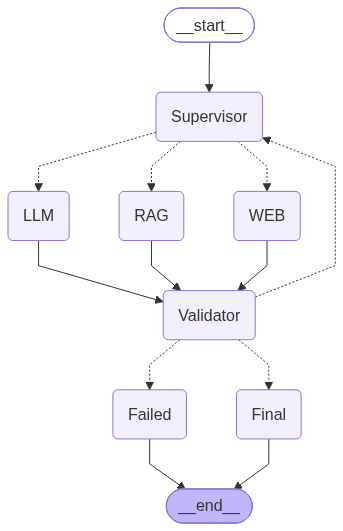

In [85]:
from IPython.display import (Image, display,)

display(Image(app.get_graph().draw_mermaid_png()))

In [86]:
def ask_agent(question: str):

    initial_state = {

                        "question": question,
                        "attempts": 0,
                        "used_routes": [],
                        "validation_feedback": "",
                        "validation_passed": False,
                        "validation_score": 0,
                        "context": "",
                        "draft_answer": "",
                        "final_answer": "",
                    }


    result = app.invoke(
                        initial_state,
                        {"recursion_limit": 30}
                        )


    print("\n\n================================")

    print("FINAL RESULT")

    print("================================")

    print("Question:")

    print(result["question"])


    print("\nFinal Route:")

    print(result.get("route"))


    print("\nRoutes Tried:")

    print(
        result.get(
            "used_routes"
        )
    )


    print(
        "\nValidation Score:"
    )

    print(
        result.get(
            "validation_score"
        )
    )


    print(
        "\nValidation Feedback:"
    )

    print(
        result.get(
            "validation_feedback"
        )
    )


    print(
        "\nFinal Answer:"
    )

    print(
        result["final_answer"]
    )


    return result

In [87]:
result = ask_agent("hi can you help me?")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: User greeting and general request, no specific information needed.

-> ROUTER ->
Routing to: LLM

LLM NODE
LLM Answer: Sure thing! What do you need help with? Whether it’s a quick fact, a deeper explanation, or some guidance on a project, just let me know and I’ll do my best to assist.

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: The response is relevant, correct, and appropriately invites the user to specify their needs. No hallucinations or grounding issues are present. Overall, it meets the criteria for a good answer.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:
hi can you help me?

Final Route:
LLM

Routes Tried:
['LLM']

Validation Score:
9

Validation Feedback:
The response is relevant, correct, and appropriately invites the user to specify their needs. No hallucinations or grounding issues are present. Overall, it meets the criteria for a good answer.

Final Answer:
Sure thing

In [88]:
result = ask_agent("can you tell me the current GDP of china?")


SUPERVISOR NODE
Selected Route: WEB
Reasoning: The user requests the current GDP of China, which is recent economic data that may have changed and is not covered by the USA-focused RAG knowledge base. Therefore the WEB node should be used to fetch up-to-date information.

-> ROUTER ->
Routing to: WEB

WEB SEARCH NODE
Web search completed.
WEB Answer: **China’s most recent GDP figures (as of the latest data available in 2025–2026)**  

| Currency & Time | GDP | Source |
|-----------------|-----|--------|
| **35,450 billion CNY** (current‑price, local currency) – Q3 2025 | 35,450.02 billion CNY | TheGlobalEconomy.com (latest quarterly data) |
| **$19,498 billion USD** (current‑price, nominal) – 2025 | 19,498.04 billion USD | TradingEconomics (World Bank‑based figure for 2025) |
| **$20.85 trillion USD** (current‑price, nominal) – 2026 (IMF projection) | 20.85 trillion USD | Worldometers (IMF 2026 estimate) |

### What this means
* **Local‑currency figure** (CNY) reflects China’s GDP in 

In [89]:
result = ask_agent("What are the major economic challenges of the USA?")


SUPERVISOR NODE
Selected Route: RAG
Reasoning: The question asks about the major economic challenges of the USA, which is directly related to U.S. economic topics covered by the RAG knowledge base. It does not request real‑time or current data, so the RAG node is the best fit.

-> ROUTER ->
Routing to: RAG

RAG NODE
Retrieved Documents: 3
RAG Answer: The major economic challenges facing the United States include:

- **Inflation**  
- **Public debt**  
- **Income inequality**  
- **Housing costs**  
- **Competition from other global economies**

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: The answer directly addresses the question, accurately reflects the information provided in the source context, and contains no unsupported claims. It is relevant, correct, and complete within the scope of the retrieved content.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:
What are the major economic challenges of the USA?

Final Route:
RAG

Rout

In [90]:
result = ask_agent("What does the document say about future growth of the U.S. economy?")


SUPERVISOR NODE
Selected Route: RAG
Reasoning: The question asks for information about future growth of the U.S. economy as stated in internal documents, which is directly covered by the RAG knowledge base focused on U.S. economic topics.

-> ROUTER ->
Routing to: RAG

RAG NODE
Retrieved Documents: 3
RAG Answer: The supplied context does not contain any explicit statement about the future growth of the U.S. economy.

VALIDATOR NODE
Validation Passed: False
Score: 5
Feedback: The answer claims that the context contains no explicit statement about future growth, but the source does mention "long‑term economic growth," which is a forward‑looking statement. Therefore the response is incomplete and not fully accurate. It also does not reference the retrieved context, violating the source‑grounding requirement. The answer should acknowledge the mention of long‑term growth and quote the relevant passage.

-> VALIDATION ROUTER ->
Validation FAILED
Returning to Supervisor...

SUPERVISOR NODE
S

In [91]:
result = ask_agent("can you give me current update of the usa and iran war?")


SUPERVISOR NODE
Selected Route: WEB
Reasoning: The user is asking for a current update on the USA and Iran conflict, which requires up-to-date information that may have changed recently. This falls under the criteria for the WEB node, which is designed to fetch real-time or recent data.

-> ROUTER ->
Routing to: WEB

WEB SEARCH NODE
Web search completed.
WEB Answer: **Current status of the U.S.–Iran conflict (as of early September 2026)**  

| Date | What happened | Who was targeted | Source |
|------|---------------|------------------|--------|
| **Sept 3–4** | Iran launched a series of drone‑ and missile strikes against U.S. military bases in the United Arab Emirates, Kuwait and Jordan.  The attacks are part of a broader Iranian campaign to erode U.S. resolve and to force the U.S. to “surrender.”  Iran’s hard‑line Islamic Revolutionary Guard Corps (IRGC) faction says it is dissatisfied with the war’s current trajectory and wants to secure control of the Strait of Hormuz. | U.S. base

In [92]:
result = ask_agent("hi my name is Hemant how you are doing?")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: The user is greeting and asking a casual question, which is general knowledge and does not require current data or the USA economy knowledge base.

-> ROUTER ->
Routing to: LLM

LLM NODE
LLM Answer: Hello Hemant! I’m doing well—thanks for asking. How can I help you today?

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: The answer is relevant, correct, complete, and contains no hallucinations. It appropriately addresses the greeting and offers further assistance, meeting all evaluation criteria.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:
hi my name is Hemant how you are doing?

Final Route:
LLM

Routes Tried:
['LLM']

Validation Score:
9

Validation Feedback:
The answer is relevant, correct, complete, and contains no hallucinations. It appropriately addresses the greeting and offers further assistance, meeting all evaluation criteria.

Final Answer:
Hello Hemant! I’m doing well—thanks 

In [93]:
result = ask_agent("can you give me salary of Rumani Dua")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: The user requests personal salary information for an individual, which is not covered by the RAG (USA economy) or WEB (current info) categories. It is a personal data query that falls under general knowledge but requires a refusal or safe completion. The LLM node is appropriate for handling such requests.

-> ROUTER ->
Routing to: LLM

LLM NODE
LLM Answer: I’m sorry, but I can’t help with that.

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: The response appropriately refuses to provide the requested personal data, complying with policy. No factual errors or hallucinations.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:
can you give me salary of Rumani Dua

Final Route:
LLM

Routes Tried:
['LLM']

Validation Score:
9

Validation Feedback:
The response appropriately refuses to provide the requested personal data, complying with policy. No factual errors or hallucinations.

Final Answer:
I’

### **2) LangGraph Architecture**

### **3) State management in LangGraph**

### **4) StaleGraph vs Graph API vs Functional API**

### **5) Send API**

### **6) Command API**

### **7) Persistence/Checkpoint**

### **8) Memory**

### **9) Human IN Loop**

### **10) Streaming**

### **11) Multi-Agents**

### **12) Caching**

### **13) Fault Tolerance**

### **14) Async LangGraph**